# Phase 4 — Daily XGBoost Walk-Forward

Evaluates whether a gradient-boosted tree model trained on **daily bars** can
produce a positive OOS Sharpe ratio for BTC/USD, ETH/USD, and SOL/USD.

**Kill criterion**: median OOS Sharpe > 0 on ≥ 2 of 3 symbols → proceed to live.

---
Sections:
1. Setup
2. Data Ingestion
3. Feature Engineering Check
4. Label Distribution Check
5. Walk-Forward Backtest
6. Per-Fold Metrics
7. SHAP Feature Importance
8. Kill Criterion Evaluation

## 1. Setup

In [1]:
import sys
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add repo root to path so bot package is importable
sys.path.insert(0, os.path.abspath(".."))

from bot.data.fetcher import fetch_daily_bars
from bot.features.rolling import compute_features
from bot.features.labeling import make_daily_vol_adjusted_labels
from bot.models.xgboost_model import train_xgboost, compute_shap_importance
from bot.backtest.engine import apply_signal_policy
from bot.backtest.walkforward import run_walkforward
from bot.utils.credentials import load_credentials
from bot.config import (
    DAILY_LOOKBACK_DAYS,
    DAILY_WALKFORWARD_TRAIN_BARS,
    DAILY_WALKFORWARD_VAL_BARS,
    DAILY_WALKFORWARD_TEST_BARS,
    DAILY_WALKFORWARD_N_FOLDS,
    DAILY_ATR_WINDOW,
    DAILY_FORWARD_BARS,
)

warnings.filterwarnings("default", category=UserWarning)

print("Config")
print(f"  DAILY_LOOKBACK_DAYS      = {DAILY_LOOKBACK_DAYS}")
print(f"  DAILY_WALKFORWARD_TRAIN_BARS = {DAILY_WALKFORWARD_TRAIN_BARS}")
print(f"  DAILY_WALKFORWARD_VAL_BARS   = {DAILY_WALKFORWARD_VAL_BARS}")
print(f"  DAILY_WALKFORWARD_TEST_BARS  = {DAILY_WALKFORWARD_TEST_BARS}")
print(f"  DAILY_WALKFORWARD_N_FOLDS    = {DAILY_WALKFORWARD_N_FOLDS}")

Config
  DAILY_LOOKBACK_DAYS      = 730
  DAILY_WALKFORWARD_TRAIN_BARS = 350
  DAILY_WALKFORWARD_VAL_BARS   = 120
  DAILY_WALKFORWARD_TEST_BARS  = 120
  DAILY_WALKFORWARD_N_FOLDS    = 2


In [2]:
# Load API credentials from .env
api_key, secret_key = load_credentials()
print(f"Credentials loaded (key prefix: {api_key[:8]}...)")

Credentials loaded.
Credentials loaded (key prefix: PKRGPVBR...)


## 2. Data Ingestion

In [3]:
SYMBOLS = ["BTC/USD", "ETH/USD", "SOL/USD"]

raw_bars: dict[str, pd.DataFrame] = {}

for sym in SYMBOLS:
    df = fetch_daily_bars(api_key, secret_key, symbol=sym, days_back=DAILY_LOOKBACK_DAYS)
    raw_bars[sym] = df
    print(f"{sym}: {len(df)} bars — {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

BTC/USD: 729 bars — 2024-04-20 → 2026-04-18
ETH/USD: 729 bars — 2024-04-20 → 2026-04-18
SOL/USD: 601 bars — 2024-08-26 → 2026-04-18


In [4]:
# Quick sanity: with 2 folds and rolling windows, need ~710 bars
# Fold 2 spans indices [120:710], so 710 total bars needed
for sym, df in raw_bars.items():
    n = len(df)
    min_needed_2fold = 120 + DAILY_WALKFORWARD_TRAIN_BARS + DAILY_WALKFORWARD_VAL_BARS + DAILY_WALKFORWARD_TEST_BARS
    status = "OK" if n >= min_needed_2fold else "WARN: too short for 2 folds"
    print(f"{sym}: {n} bars  [{status}] (need {min_needed_2fold} for 2 folds)")

BTC/USD: 729 bars  [OK] (need 710 for 2 folds)
ETH/USD: 729 bars  [OK] (need 710 for 2 folds)
SOL/USD: 601 bars  [WARN: too short for 2 folds] (need 710 for 2 folds)


## 3. Feature Engineering Check

In [5]:
df_btc = raw_bars["BTC/USD"].copy()

df_btc_feat = compute_features(
    df_btc,
    extended=True,
    regime=True,
    timeframe="daily",
)

print(f"Rows after feature computation: {len(df_btc_feat)}")
print(f"Columns ({len(df_btc_feat.columns)}):")
for col in df_btc_feat.columns:
    print(f"  {col}")

Rows after feature computation: 651
Columns (18):
  timestamp
  open
  high
  low
  close
  volume
  rolling_mean
  rolling_std
  zscore
  return
  return_lag1
  return_lag2
  return_lag3
  momentum_12h
  volume_zscore_20
  vol_percentile
  trend_slope
  atr_normalized_return


In [6]:
# Verify no NaN values remain after warm-up drop (task 4.5)
nan_counts = df_btc_feat.isnull().sum()
print("NaN counts per column:")
print(nan_counts[nan_counts > 0])
assert nan_counts.sum() == 0, "Unexpected NaN values after feature computation"
print("\nAll columns are NaN-free.")

NaN counts per column:
Series([], dtype: int64)

All columns are NaN-free.


## 4. Label Distribution Check

In [7]:
# Use first 400 bars as a training slice to fit thresholds
df_train_slice = df_btc_feat.iloc[:DAILY_WALKFORWARD_TRAIN_BARS].copy()

X_tr, y_tr, lower, upper = make_daily_vol_adjusted_labels(
    df_train_slice,
    compute_thresholds=True,
)

print(f"Training slice: {len(df_train_slice)} bars → {len(y_tr)} labeled samples")
print(f"Label 0 (flat):  {(y_tr == 0).sum()} ({(y_tr == 0).mean():.1%})")
print(f"Label 1 (long):  {(y_tr == 1).sum()} ({(y_tr == 1).mean():.1%})")
print(f"Thresholds: lower={lower:.4f}, upper={upper:.4f}")

Training slice: 350 bars → 199 labeled samples
Label 0 (flat):  99 (49.7%)
Label 1 (long):  100 (50.3%)
Thresholds: lower=-0.0000, upper=0.0000


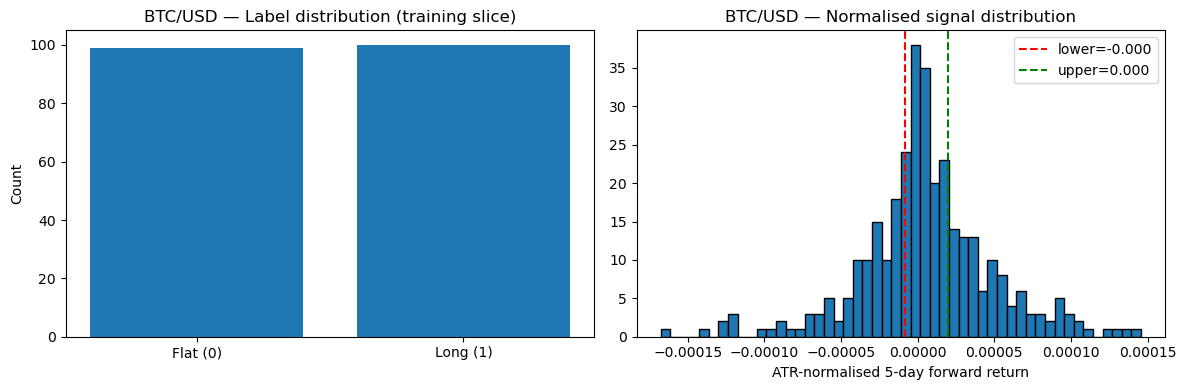

In [8]:
# Visualise label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Flat (0)", "Long (1)"], [y_tr.value_counts().get(0, 0), y_tr.value_counts().get(1, 0)])
axes[0].set_title("BTC/USD — Label distribution (training slice)")
axes[0].set_ylabel("Count")

# Normalised signal distribution
df_train_slice_copy = df_train_slice.copy()
from bot.features.labeling import compute_atr  # type: ignore
atr = compute_atr(df_train_slice_copy, window=DAILY_ATR_WINDOW)
fwd = (df_train_slice_copy["close"].shift(-DAILY_FORWARD_BARS) - df_train_slice_copy["close"]) / df_train_slice_copy["close"]
signal = (fwd / atr).dropna()
axes[1].hist(signal, bins=50, edgecolor="black")
axes[1].axvline(lower, color="red", linestyle="--", label=f"lower={lower:.3f}")
axes[1].axvline(upper, color="green", linestyle="--", label=f"upper={upper:.3f}")
axes[1].set_title("BTC/USD — Normalised signal distribution")
axes[1].set_xlabel("ATR-normalised 5-day forward return")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Walk-Forward Backtest

In [10]:
# Diagnostic: show bar counts after feature engineering for each symbol
print("Bar counts AFTER feature engineering (to verify no warm-up loss issues):")
for sym in SYMBOLS:
    df_raw = raw_bars[sym]
    df_feat = compute_features(df_raw, extended=True, regime=True, timeframe="daily")
    bars_raw = len(df_raw)
    bars_feat = len(df_feat)
    bars_lost = bars_raw - bars_feat
    fold2_ok = bars_feat >= 710
    status = "✓ Fold 2 OK" if fold2_ok else "✗ Fold 2 will SKIP"
    print(f"  {sym}: {bars_raw} raw → {bars_feat} feat (lost {bars_lost}) [{status}]")

Bar counts AFTER feature engineering (to verify no warm-up loss issues):
  BTC/USD: 729 raw → 651 feat (lost 78) [✗ Fold 2 will SKIP]
  ETH/USD: 729 raw → 651 feat (lost 78) [✗ Fold 2 will SKIP]
  SOL/USD: 601 raw → 523 feat (lost 78) [✗ Fold 2 will SKIP]


In [11]:
def feature_fn(df):
    return compute_features(df, extended=True, regime=True, timeframe="daily")

all_results: dict[str, list[dict]] = {}

for sym in SYMBOLS:
    print(f"\n{'='*60}")
    print(f"Running walk-forward for {sym}")
    print(f"{'='*60}")
    
    # Fetch raw data for this symbol
    df = fetch_daily_bars(api_key, secret_key, symbol=sym, days_back=DAILY_LOOKBACK_DAYS)
    
    results = run_walkforward(
        df=df,
        n_folds=DAILY_WALKFORWARD_N_FOLDS,
        train_bars=DAILY_WALKFORWARD_TRAIN_BARS,
        val_bars=DAILY_WALKFORWARD_VAL_BARS,
        test_bars=DAILY_WALKFORWARD_TEST_BARS,
        feature_fn=feature_fn,
        label_fn=make_daily_vol_adjusted_labels,
        model_fn=train_xgboost,
        policy_fn=apply_signal_policy,
    )
    all_results[sym] = results
    
    for r in results:
        status = "SKIP" if r["sharpe_ratio"] is None else "OK"
        print(f"  Fold {r['fold']}: [{status}] Sharpe={r['sharpe_ratio']}, Return={r['total_return']}")


Running walk-forward for BTC/USD
  Fold 1: [OK] Sharpe=-19.602151013649827, Return=-0.12418695041053252
  Fold 2: [OK] Sharpe=8.994545989097542, Return=0.07461465019309887

Running walk-forward for ETH/USD
  Fold 1: [OK] Sharpe=-4.440084245737756, Return=-0.06186387350567135
  Fold 2: [OK] Sharpe=-17.918870144865323, Return=-0.13395089324153597

Running walk-forward for SOL/USD
  Fold 1: [OK] Sharpe=-6.507732283423845, Return=-0.0929925645027534
  Fold 2: [SKIP] Sharpe=None, Return=None


/tmp/ipykernel_89587/4191002681.py:14: UserWarning: Walk-forward fold 2 failed and will be skipped: Not enough bars for fold 2: need 710, have 601.  Reduce n_folds or bar counts in config.
  results = run_walkforward(


## 6. Per-Fold Metrics

In [12]:
for sym in SYMBOLS:
    print(f"\n=== {sym} ===")
    rows = []
    for r in all_results[sym]:
        rows.append({
            "fold":         r["fold"],
            "test_start":   r["test_start"],
            "test_end":     r["test_end"],
            "sharpe_ratio": r["sharpe_ratio"],
            "total_return": r["total_return"],
            "max_drawdown": r["max_drawdown"],
            "num_trades":   r["num_trades"],
            "win_rate":     r["win_rate"],
            "brier_score":  r["brier_score"],
        })
    df_metrics = pd.DataFrame(rows).set_index("fold")
    
    # Format numeric columns
    for col in ["sharpe_ratio", "total_return", "max_drawdown", "win_rate", "brier_score"]:
        df_metrics[col] = df_metrics[col].apply(
            lambda x: f"{x:.4f}" if x is not None else "N/A"
        )
    
    display(df_metrics)


=== BTC/USD ===


,test_start,test_end,sharpe_ratio,total_return,max_drawdown,num_trades,win_rate,brier_score
fold,,,,,,,,
1,470,589,-19.6022,-0.1242,-0.1491,3,0.3333,0.2167
2,590,709,8.9945,0.0746,-0.0579,5,0.8000,0.4809



=== ETH/USD ===


,test_start,test_end,sharpe_ratio,total_return,max_drawdown,num_trades,win_rate,brier_score
fold,,,,,,,,
1,470,589,-4.4401,-0.0619,-0.2284,4,0.5000,0.4613
2,590,709,-17.9189,-0.1340,-0.1394,5,0.4000,0.3941



=== SOL/USD ===


,test_start,test_end,sharpe_ratio,total_return,max_drawdown,num_trades,win_rate,brier_score
fold,,,,,,,,
1,470.0,589.0,-6.5077,-0.0930,-0.1792,2.0,0.0000,0.3981
2,NaN,NaN,nan,nan,nan,NaN,nan,nan


## 7. SHAP Feature Importance

In [13]:
for sym in SYMBOLS:
    print(f"\n=== {sym} — SHAP importance per fold ===")
    
    shap_records = []
    for r in all_results[sym]:
        if r.get("shap_importance") is not None:
            row = {"fold": r["fold"]}
            row.update(r["shap_importance"])
            shap_records.append(row)
    
    if not shap_records:
        print("  No SHAP data available (no valid folds).")
        continue
    
    df_shap = pd.DataFrame(shap_records).set_index("fold")
    display(df_shap.round(5))
    
    # Mean importance across folds
    mean_imp = df_shap.mean().sort_values(ascending=False)
    print(f"\n  Top features (mean |SHAP|):")
    for feat, val in mean_imp.head(10).items():
        print(f"    {feat:30s}  {val:.5f}")


=== BTC/USD — SHAP importance per fold ===


,rolling_mean,zscore,return_lag2,momentum_12h,return_lag1,return_lag3,return,rolling_std,volume_zscore_20
fold,,,,,,,,,
1,1.45299,0.42897,0.39820,0.38884,0.33699,0.24447,0.18285,0.11953,0.10282
2,1.05981,0.47646,0.26051,0.42049,0.33067,0.44418,0.37114,0.89990,0.05361



  Top features (mean |SHAP|):
    rolling_mean                    1.25640
    rolling_std                     0.50971
    zscore                          0.45271
    momentum_12h                    0.40467
    return_lag3                     0.34432
    return_lag1                     0.33383
    return_lag2                     0.32935
    return                          0.27699
    volume_zscore_20                0.07821

=== ETH/USD — SHAP importance per fold ===


,rolling_std,rolling_mean,momentum_12h,return_lag2,zscore,return_lag3,return,volume_zscore_20,return_lag1
fold,,,,,,,,,
1,2.07634,0.71894,0.53893,0.40406,0.37513,0.37506,0.36901,0.16256,0.10808
2,0.82260,0.42604,0.22515,0.23839,0.27917,0.10679,0.58681,0.24668,0.31377



  Top features (mean |SHAP|):
    rolling_std                     1.44947
    rolling_mean                    0.57249
    return                          0.47791
    momentum_12h                    0.38204
    zscore                          0.32715
    return_lag2                     0.32122
    return_lag3                     0.24092
    return_lag1                     0.21093
    volume_zscore_20                0.20462

=== SOL/USD — SHAP importance per fold ===


,rolling_mean,rolling_std,return_lag1,return_lag2,zscore,volume_zscore_20,momentum_12h,return_lag3,return
fold,,,,,,,,,
1,1.74531,0.71765,0.26996,0.20449,0.14176,0.1233,0.11643,0.1034,0.09823



  Top features (mean |SHAP|):
    rolling_mean                    1.74531
    rolling_std                     0.71765
    return_lag1                     0.26996
    return_lag2                     0.20449
    zscore                          0.14176
    volume_zscore_20                0.12330
    momentum_12h                    0.11643
    return_lag3                     0.10340
    return                          0.09823


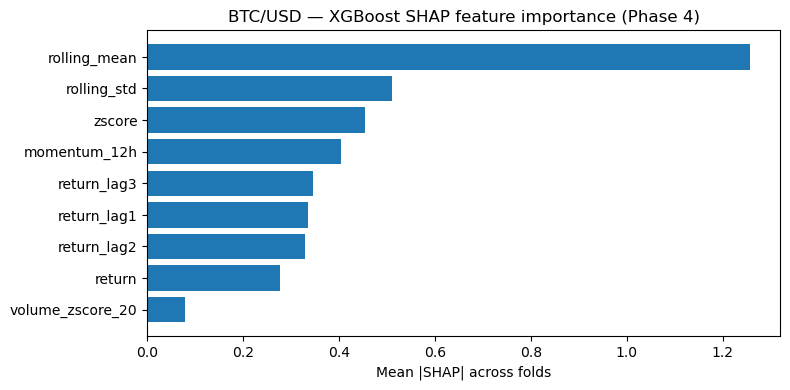

In [14]:
# Visualise mean SHAP importance for BTC
sym = "BTC/USD"
shap_records = [
    {"fold": r["fold"], **r["shap_importance"]}
    for r in all_results[sym]
    if r.get("shap_importance") is not None
]

if shap_records:
    df_shap_btc = pd.DataFrame(shap_records).set_index("fold")
    mean_imp = df_shap_btc.mean().sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, max(4, len(mean_imp) * 0.4)))
    ax.barh(mean_imp.index, mean_imp.values)
    ax.set_xlabel("Mean |SHAP| across folds")
    ax.set_title(f"{sym} — XGBoost SHAP feature importance (Phase 4)")
    plt.tight_layout()
    plt.show()
else:
    print("No SHAP data for BTC/USD.")

## 8. Kill Criterion Evaluation

**Pass condition**: median OOS Sharpe ratio > 0 on **≥ 2 of 3 symbols**.

- PASS → proceed to live deployment (Phase 5)
- FAIL → investigate feature / label improvements before deployment

In [15]:
kill_criterion_results = {}

for sym in SYMBOLS:
    sharpe_values = [
        r["sharpe_ratio"]
        for r in all_results[sym]
        if r["sharpe_ratio"] is not None
    ]
    
    if not sharpe_values:
        median_sharpe = None
        passes = False
    else:
        median_sharpe = float(np.median(sharpe_values))
        passes = median_sharpe > 0
    
    kill_criterion_results[sym] = {
        "median_sharpe": median_sharpe,
        "n_valid_folds": len(sharpe_values),
        "passes": passes,
    }
    
    status = "PASS" if passes else "FAIL"
    print(f"  {sym:<12s}: median Sharpe = {median_sharpe!s:>8s}  [{status}]")

symbols_passing = sum(1 for v in kill_criterion_results.values() if v["passes"])
overall = symbols_passing >= 2

print(f"\n{'='*50}")
print(f"Symbols passing: {symbols_passing}/3")
print(f"Overall kill criterion: {'PASS — proceed to live (Phase 5)' if overall else 'FAIL — do not deploy'}")
print(f"{'='*50}")

  BTC/USD     : median Sharpe = -5.3038025122761425  [FAIL]
  ETH/USD     : median Sharpe = -11.17947719530154  [FAIL]
  SOL/USD     : median Sharpe = -6.507732283423845  [FAIL]

Symbols passing: 0/3
Overall kill criterion: FAIL — do not deploy
